## 1 - GET DATA

In [132]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/Fertility_Health_Dataset_2026.csv")

with pd.option_context('display.max_columns', None):
    print(df.head())

   Couple_ID  Female_Age  Male_Age   BMI Menstrual_Regularity PCOS  \
0          1          26        35  22.6              Regular   No   
1          2          39        30  28.0              Regular   No   
2          3          34        35  24.1              Regular  Yes   
3          4          30        22  19.6              Regular   No   
4          5          27        40  33.6            Irregular   No   

  Stress_Level Smoking Alcohol_Intake  Sperm_Count_Million_per_ml  Motility_%  \
0         High      No            NaN                        75.7        74.1   
1         High     Yes       Moderate                        25.2        27.4   
2          Low      No           High                        64.0        74.5   
3         High      No           High                        87.3        31.9   
4          Low      No           High                       116.9        51.3   

   Trying_Duration_Months Treatment_Type Pregnancy_Outcome  
0                      13      

## 2 - PREPROCESS

In [133]:
df.drop(columns="Couple_ID", inplace=True) # Not needed

In [134]:
print(df.isnull().sum())

Female_Age                      0
Male_Age                        0
BMI                             0
Menstrual_Regularity            0
PCOS                            0
Stress_Level                    0
Smoking                         0
Alcohol_Intake                259
Sperm_Count_Million_per_ml      0
Motility_%                      0
Trying_Duration_Months          0
Treatment_Type                500
Pregnancy_Outcome               0
dtype: int64


In [135]:
print(df["Alcohol_Intake"].unique())
print(df["Treatment_Type"].unique())

[nan 'Moderate' 'High']
[nan 'Medication' 'IVF']


In [136]:
df = df.fillna("None") # Impute null objects with "None" strings. I don't think we should assume the above values.

In [137]:
CATEGORICAL_COLUMNS = [
    "Menstrual_Regularity",
    "PCOS",
    "Stress_Level",
    "Smoking",
    "Alcohol_Intake",
    "Treatment_Type",
    "Pregnancy_Outcome"
]
df = pd.get_dummies(df, columns=CATEGORICAL_COLUMNS, drop_first=True) # Encode categorical values

In [138]:
with pd.option_context('display.max_columns', None):
    print(df.head())

   Female_Age  Male_Age   BMI  Sperm_Count_Million_per_ml  Motility_%  \
0          26        35  22.6                        75.7        74.1   
1          39        30  28.0                        25.2        27.4   
2          34        35  24.1                        64.0        74.5   
3          30        22  19.6                        87.3        31.9   
4          27        40  33.6                       116.9        51.3   

   Trying_Duration_Months  Menstrual_Regularity_Regular  PCOS_Yes  \
0                      13                          True     False   
1                      35                          True     False   
2                      13                          True      True   
3                      31                          True     False   
4                      21                         False     False   

   Stress_Level_Low  Stress_Level_Medium  Smoking_Yes  \
0             False                False        False   
1             False             

In [139]:
TARGET_COL = "Pregnancy_Outcome_Success"
SEED = 77

y_col_index = df.columns.get_loc(TARGET_COL)
X = df.drop(columns=TARGET_COL).values
y = df.iloc[:, y_col_index].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [140]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [141]:
print(X_train) # now values are machine readable, they are scaled around 0 and 1, no strings, only numbers
# We could also remove highly correlated columns and remove outliers, but I don't think this dataset
# is that extreme

[[-1.31166155  0.30298035 -1.37153413 ... -0.67910766 -0.59660054
   0.77976933]
 [-0.38612308  0.91160377 -0.9310816  ...  1.47252057  1.67616342
  -1.28243054]
 [-0.78278242 -0.18391839  1.51142786 ... -0.67910766  1.67616342
  -1.28243054]
 ...
 [ 1.20051429  1.03332846 -0.27040281 ... -0.67910766  1.67616342
  -1.28243054]
 [ 0.14275604  0.54642972  1.31122216 ... -0.67910766 -0.59660054
   0.77976933]
 [-0.65056264 -0.54909245 -0.91106103 ... -0.67910766 -0.59660054
   0.77976933]]


## 3, 4, 5 - MODEL AND TECHNIQUES

Define Varied Models

In [142]:
import tensorflow as tf

MODEL_TECHNIQUE = {
    "NONE": tf.keras.Sequential([
            tf.keras.layers.Input(shape=(X_train.shape[1],)),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid")
    ]),
    "DROPOUT": tf.keras.Sequential([
              tf.keras.layers.Input(shape=(X_train.shape[1],)),
              tf.keras.layers.Dense(32, activation="relu"),
              tf.keras.layers.Dropout(0.5),
              tf.keras.layers.Dense(16, activation="relu"),
              tf.keras.layers.Dropout(0.5),
              tf.keras.layers.Dense(8, activation="relu"),
              tf.keras.layers.Dense(1, activation="sigmoid")
    ]),
    "BATCH_NORM": tf.keras.Sequential([
                  tf.keras.layers.Input(shape=(X_train.shape[1],)),
                  tf.keras.layers.Dense(32, activation="relu"),
                  tf.keras.layers.BatchNormalization(),
                  tf.keras.layers.Dense(16, activation="relu"),
                  tf.keras.layers.BatchNormalization(),
                  tf.keras.layers.Dense(8, activation="relu"),
                  tf.keras.layers.BatchNormalization(),
                  tf.keras.layers.Dense(1, activation="sigmoid")
    ]),
    "REGULARIZATION": tf.keras.Sequential([
                      tf.keras.layers.Input(shape=(X_train.shape[1],)),
                      tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01),),
                      tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01),),
                      tf.keras.layers.Dense(8, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01),),
                      tf.keras.layers.Dense(1, activation="sigmoid")
    ])
}

Define model training

In [143]:
import time

EPOCHS = 500
DEFAULT_BATCH_SIZE = 32
EARLY_STOP_CALLBACK = [
    tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True)
]

def run_model(batch_size=DEFAULT_BATCH_SIZE, model=MODEL_TECHNIQUE["NONE"], enable_early_stop=False):
    model.compile(
        optimizer= tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        loss="binary_crossentropy"
    )

    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0,
        callbacks=(EARLY_STOP_CALLBACK if enable_early_stop else [])
    )

    end = time.time()
    full_batch_elapsed = end - start
    return model, history, full_batch_elapsed

Define Model Eval

In [144]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_model(model, history, elapsed):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"FULL_BATCH DURATION IS:  {elapsed}")
    print(f"FULL_BATCH ACCURACY IS:  {accuracy}")
    print(f"FULL_BATCH PRECISION IS: {precision}")
    print(f"FULL_BATCH RECALL IS:    {recall}")

    plt.figure()
    plt.plot(history.history["loss"], color='green', label='Training Loss')
    plt.plot(history.history["val_loss"], color='red', label='Validation Loss')
    plt.title('Loss Plot')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    _ = plt.legend()

    return accuracy, precision, recall

## FULL BATCH 1/6

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
FULL_BATCH DURATION IS:  38.463444232940674
FULL_BATCH ACCURACY IS:  0.775
FULL_BATCH PRECISION IS: 0.7655172413793103
FULL_BATCH RECALL IS:    0.9823008849557522


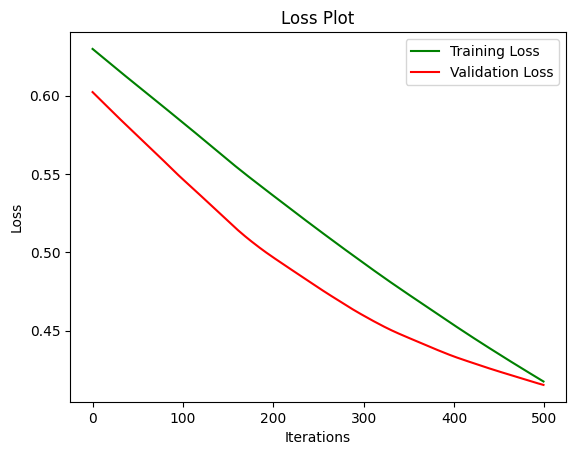

In [145]:
full_batch_model, full_batch_history, full_batch_elapsed = run_model(X_train.shape[0])
full_acc, full_prec, full_rec = evaluate_model(full_batch_model, full_batch_history, full_batch_elapsed)

## MINI BATCH 2/6
- In comparison to full batch, mini batch training converges way faster.
- Mini batch statistics seem to be more reputable all around 85%
- Full batch statistics varies from 70% to 97%
- Both around 50s

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
FULL_BATCH DURATION IS:  48.969868659973145
FULL_BATCH ACCURACY IS:  0.7625
FULL_BATCH PRECISION IS: 0.8151260504201681
FULL_BATCH RECALL IS:    0.8584070796460177


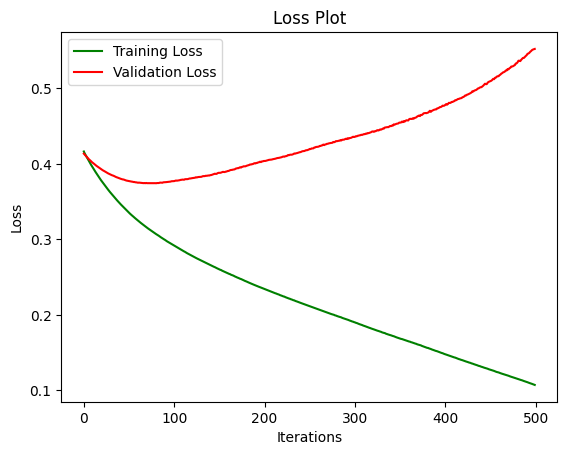

In [146]:
mini_batch_model, mini_batch_history, mini_batch_elapsed = run_model()
mini_acc, mini_prec, mini_rec = evaluate_model(mini_batch_model, mini_batch_history, mini_batch_elapsed)

## DROPOUT 3/6
Dropout shutdowns random neurons, we can see the loss is more jagged than the previous runs. Validation looks good but stats are comparable to mini batch.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
FULL_BATCH DURATION IS:  50.93599200248718
FULL_BATCH ACCURACY IS:  0.81875
FULL_BATCH PRECISION IS: 0.8962264150943396
FULL_BATCH RECALL IS:    0.8407079646017699


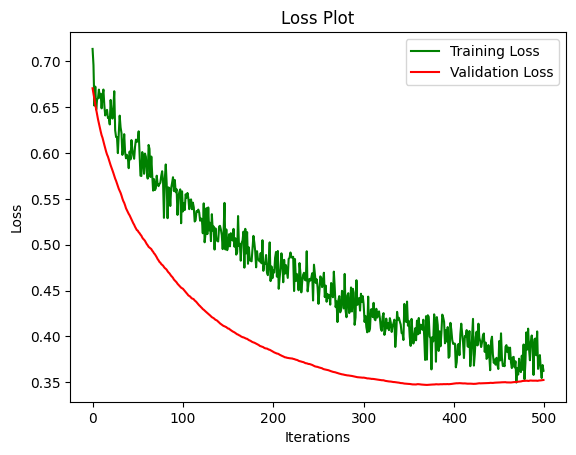

In [147]:
drop_model, drop_history, drop_elapsed = run_model(model=MODEL_TECHNIQUE["DROPOUT"])
drop_acc, drop_prec, drop_rec = evaluate_model(drop_model, drop_history, drop_elapsed)

## BATCH NORM 4/6
Normalizes the inputs so they are no so varied which could confuse the model. Training looks good and jagged, but validation failed. Stats are comparable to mini batch however.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
FULL_BATCH DURATION IS:  56.07293963432312
FULL_BATCH ACCURACY IS:  0.79375
FULL_BATCH PRECISION IS: 0.8278688524590164
FULL_BATCH RECALL IS:    0.8938053097345132


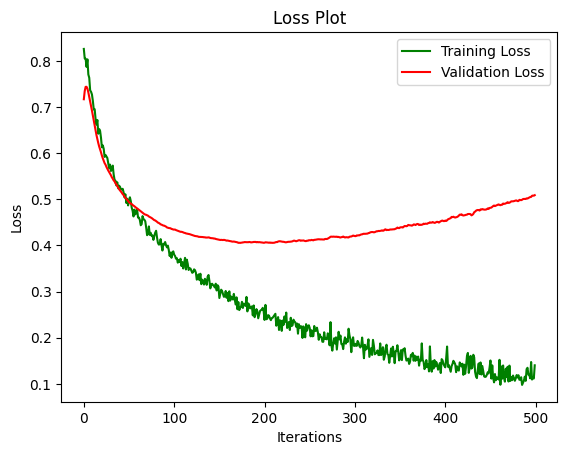

In [148]:
b_norm_model, b_norm_history, b_norm_elapsed = run_model(model=MODEL_TECHNIQUE["BATCH_NORM"])
b_norm_acc, b_norm_prec, b_norm_rec = evaluate_model(b_norm_model, b_norm_history, b_norm_elapsed)

## REGULARIZATION 5/6
Reduces overfitting by penalizing memorization it seems. It worked cause loss looks good compared to the previous runs. The stats are still comparable to mini batch

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
FULL_BATCH DURATION IS:  50.14278054237366
FULL_BATCH ACCURACY IS:  0.80625
FULL_BATCH PRECISION IS: 0.8416666666666667
FULL_BATCH RECALL IS:    0.8938053097345132


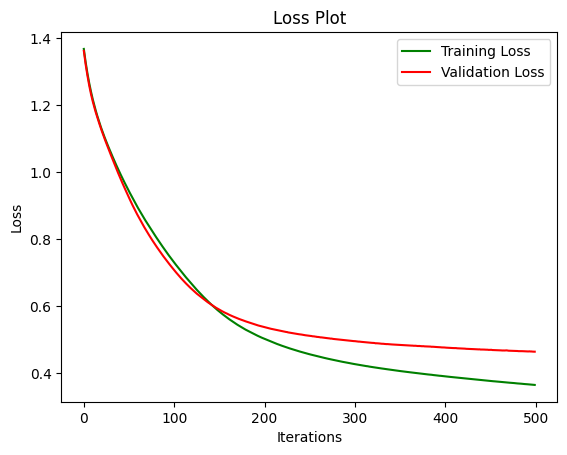

In [149]:
reg_model, reg_history, reg_elapsed = run_model(model=MODEL_TECHNIQUE["REGULARIZATION"])
reg_acc, reg_prec, reg_rec = evaluate_model(reg_model, reg_history, reg_elapsed)

# EARLY STOP 6/6
This technique stop the training base on how long the validation loss stagnates. It seems my model stopped really early cause it look weird. However, stats are decent and it only took 5 seconds.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
FULL_BATCH DURATION IS:  5.187587261199951
FULL_BATCH ACCURACY IS:  0.7625
FULL_BATCH PRECISION IS: 0.8151260504201681
FULL_BATCH RECALL IS:    0.8584070796460177


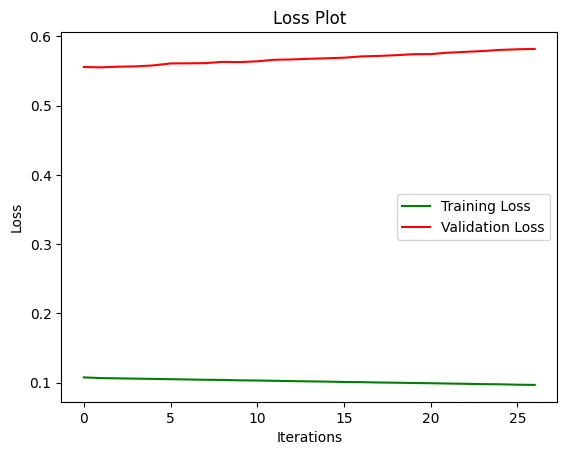

In [150]:
stop_model, stop_history, stop_elapsed = run_model(enable_early_stop=True)
stop_acc, stop_prec, stop_rec = evaluate_model(stop_model, stop_history, stop_elapsed)

## 6 - COMPARISON TABLE

In [151]:
print(f"Full Batch | Accuracy: {round(full_acc, 3)} | Precision: {round(full_prec, 3)} | Recall: {round(full_rec, 3)} | Elapsed: {round(full_batch_elapsed, 3)}")
print(f"Mini Batch | Accuracy: {round(mini_acc, 3)} | Precision: {round(mini_prec, 3)} | Recall: {round(mini_rec, 3)} | Elapsed: {round(mini_batch_elapsed, 3)}")
print(f"Dropout    | Accuracy: {round(drop_acc, 3)} | Precision: {round(drop_prec, 3)} | Recall: {round(drop_rec, 3)} | Elapsed: {round(drop_elapsed, 3)}")
print(f"Batch Norm | Accuracy: {round(b_norm_acc, 3)} | Precision: {round(b_norm_prec, 3)} | Recall: {round(b_norm_rec, 3)} | Elapsed: {round(b_norm_elapsed, 3)}")
print(f"Regularize | Accuracy: {round(reg_acc, 3)} | Precision: {round(reg_prec, 3)} | Recall: {round(reg_rec, 3)} | Elapsed: {round(reg_elapsed, 3)}")
print(f"Early Stop | Accuracy: {round(stop_acc, 3)} | Precision: {round(stop_prec, 3)} | Recall: {round(stop_rec, 3)} | Elapsed: {round(stop_elapsed, 3)}")

Full Batch | Accuracy: 0.775 | Precision: 0.766 | Recall: 0.982 | Elapsed: 38.463
Mini Batch | Accuracy: 0.762 | Precision: 0.815 | Recall: 0.858 | Elapsed: 48.97
Dropout    | Accuracy: 0.819 | Precision: 0.896 | Recall: 0.841 | Elapsed: 50.936
Batch Norm | Accuracy: 0.794 | Precision: 0.828 | Recall: 0.894 | Elapsed: 56.073
Regularize | Accuracy: 0.806 | Precision: 0.842 | Recall: 0.894 | Elapsed: 50.143
Early Stop | Accuracy: 0.762 | Precision: 0.815 | Recall: 0.858 | Elapsed: 5.188


## 7 - ANALYSIS

The accuracy, precision, and recall for all models are around the 80% varying around 10%. The only astoundings are that Full Batch recall is a bit high and took around 40s. However, my Full Batch loss plot is unusual. Early stopping only took 5s and has comparable stats to the others, but the loss plot was weird. The best loss plots were regularization and dropout.